CSCE 636 - Spring 2025
Arkan Abuyazid

Question 1

The regularization techniques mentioned in chapter 5 are L1, L2, and L1+L2 Weight Regularization.
Other names for these techniques are Lasso, Ridge, and Elastic Net, respectively.

Question 2

In [9]:
from tensorflow.keras.datasets import mnist
import numpy as np
import random

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

print(train_labels.shape)

filtered_train_images = [train_images[train_labels == i] for i in range(10)]
filtered_test_images  = [test_images[(test_labels == i)] for i in range(10)]

(60000,)


In [10]:
num_train_pairs = 0
num_test_pairs = 0

for i in range(0, 5):
    j = i * 2
    random.shuffle(filtered_train_images[j])
    random.shuffle(filtered_train_images[j+1])

    random.shuffle(filtered_test_images[j])
    random.shuffle(filtered_test_images[j+1])

    num_train_pairs += (
        min(len(filtered_train_images[j]), len(filtered_train_images[j+1]))
    )

    num_test_pairs += (
        min(len(filtered_test_images[j]), len(filtered_test_images[j+1]))
    )

print(f"num_train_pairs = {num_train_pairs}")
print(f"num_test_pairs = {num_test_pairs}")

num_train_pairs = 29071
num_test_pairs = 4814


In [11]:
train_images = np.zeros((num_train_pairs, 28 * 28))
train_labels = np.zeros((num_train_pairs))

test_images = np.zeros((num_test_pairs, 28 * 28))
test_labels = np.zeros((num_test_pairs))

print(filtered_train_images[0][0].shape)

(784,)


In [12]:
train_idx = 0
test_idx = 0
for i in range(0, 5):
    j = i * 2

    min_train_len = (
        min(len(filtered_train_images[j]), len(filtered_train_images[j+1]))
    )

    for x in range(min_train_len):
        train_images[train_idx, :] = (
            np.mean([filtered_train_images[j][x], filtered_train_images[j+1][x]], axis=0)
        )
        train_labels[train_idx] = i
        train_idx += 1

    min_test_len = (
        min(len(filtered_test_images[j]), len(filtered_test_images[j+1]))
    )

    for x in range(min_test_len):
        test_images[test_idx, :] = (
            np.mean([filtered_test_images[j][x], filtered_test_images[j+1][x]], axis=0)
        )
        test_labels[test_idx] = i
        test_idx += 1

In [13]:
import matplotlib.pyplot as plt

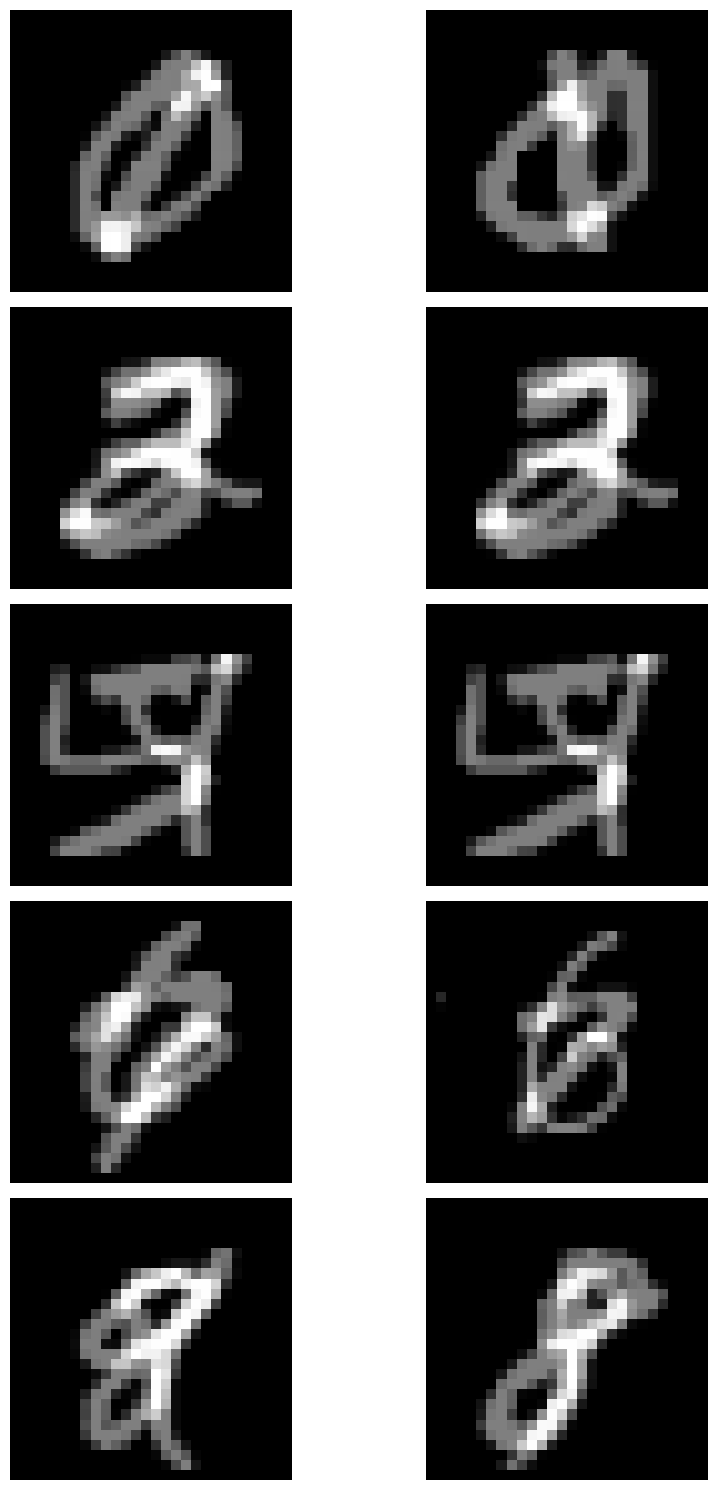

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(10, 15))

for i in range(5):
    reshaped_0 = train_images[train_labels==i][0].reshape(28, 28)
    axes[i][0].imshow(reshaped_0, cmap='gray')
    axes[i][0].axis('off')  # Turn off axis labels

    reshaped_1 = train_images[train_labels==i][1].reshape(28, 28)
    axes[i][1].imshow(reshaped_1, cmap='gray')
    axes[i][1].axis('off')  # Turn off axis labels

plt.tight_layout()
plt.show()

Question 3

In [15]:
!pip install keras-tuner
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow import keras
import keras_tuner as kt

In [16]:
def build_model(hp):
    # Define hyperparameters
    units = hp.Int('units', min_value=256, max_value=512, step=128)
    optimizer = hp.Choice('optimizer', ['rmsprop', 'adam', 'sgd'])
    learning_rate = hp.Choice('learning_rate', [0.001, 0.005, 0.01])

    # Define optimizer with learning rate
    if optimizer == "rmsprop":
        opt = optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer == "adam":
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = optimizers.SGD(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    model = Sequential()

    regularization_type = hp.Choice('regularization', values=['l1', 'l2', 'l1_l2', 'dropout', 'none'])
    l1_reg = hp.Float('l1_reg', min_value=1e-5, max_value=1e-4, step=1e-5)
    l2_reg = hp.Float('l2_reg', min_value=1e-5, max_value=1e-4, step=1e-5)
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.2, step=0.05)

    if regularization_type == 'l1':
        model.add(Dense(units, activation='relu',
                kernel_regularizer=regularizers.l1(l1_reg)))

    elif regularization_type == 'l2':
        model.add(Dense(units, activation='relu',
                kernel_regularizer=regularizers.l2(l2_reg)))

    elif regularization_type == 'l1_l2':
        model.add(Dense(units, activation='relu',
                kernel_regularizer=regularizers.l1_l2(l1=l1_reg, l2=l2_reg)))

    elif regularization_type == 'dropout' or regularization_type == 'none':
        model.add(Dense(units, activation='relu'))
        if regularization_type == 'dropout':
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [17]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=15,
    executions_per_trial=1,
    directory='my_tuner_dir',
    project_name='homework3'
)

In [18]:
tuner.search(train_images, train_labels, validation_split=0.2)

Trial 30 Complete [00h 00m 40s]
val_accuracy: 0.4132416248321533

Best val_accuracy So Far: 0.48030954599380493
Total elapsed time: 00h 10m 29s


In [19]:
best_trial = tuner.oracle.get_best_trials()[0]
best_hps   = best_trial.hyperparameters

print("Best Hyperparameters:")
for hp, val in best_hps.values.items():
    print(f"{hp}: {val}")

Best Hyperparameters:
units: 512
optimizer: adam
learning_rate: 0.001
regularization: none
l1_reg: 5e-05
l2_reg: 2e-05
dropout_rate: 0.1
tuner/epochs: 15
tuner/initial_epoch: 5
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0023


In [20]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(train_images, train_labels, epochs=15, validation_split=0.2)

val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
# best_epoch = 5
print('Best epoch: %d' % (best_epoch,))

Epoch 1/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9396 - loss: 0.2176 - val_accuracy: 0.0445 - val_loss: 4.5935
Epoch 2/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9805 - loss: 0.0567 - val_accuracy: 0.0540 - val_loss: 5.6132
Epoch 3/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9876 - loss: 0.0369 - val_accuracy: 0.2385 - val_loss: 3.9793
Epoch 4/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9926 - loss: 0.0205 - val_accuracy: 0.1457 - val_loss: 5.3852
Epoch 5/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9963 - loss: 0.0131 - val_accuracy: 0.2260 - val_loss: 5.0313
Epoch 6/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9969 - loss: 0.0111 - val_accuracy: 0.1443 - val_loss: 6.8689
Epoch 7/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accuracy: 0.3420 - val_loss: 4.1623
Epoch 8/15
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.

In [21]:
hypermodel = tuner.hypermodel.build(best_hps)
history = hypermodel.fit(train_images, train_labels, epochs=best_epoch, validation_split=0.2)

eval_result = hypermodel.evaluate(test_images, test_labels)
print("[test loss, test accuracy]:", eval_result)

Epoch 1/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9405 - loss: 0.2122 - val_accuracy: 0.1974 - val_loss: 3.0659
Epoch 2/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9825 - loss: 0.0526 - val_accuracy: 0.3881 - val_loss: 2.3504
Epoch 3/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.3470 - val_loss: 2.9607
Epoch 4/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.4249 - val_loss: 2.7290
Epoch 5/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9967 - loss: 0.0112 - val_accuracy: 0.2676 - val_loss: 4.0598
Epoch 6/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9970 - loss: 0.0121 - val_accuracy: 0.1651 - val_loss: 6.0680
Epoch 7/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9987 - loss: 0.0051 - val_accuracy: 0.4487 - val_loss: 2.8726
Epoch 8/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9985 - loss: 0.0059 - val_accuracy: 0.

What's interesting about this result is that while I did get similar train and test accuracies on my own machine, my machine came up with different hyperparameters and epochs as opposed to colab. Below are the results:

```bash
Best val_accuracy So Far: 0.6779019832611084
Total elapsed time: 00h 04m 39s
INFO:tensorflow:Oracle triggered exit
Best Hyperparameters:
units: 256
optimizer: adam
learning_rate: 0.005
regularization: l2
l1_reg: 7.000000000000001e-05
l2_reg: 2e-05
dropout_rate: 0.1
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 2
tuner/round: 0
```

```bash
Best epoch: 2
Epoch 1/2
727/727 [==============================] - 2s 2ms/step - loss: 0.1181 - accuracy: 0.9660 - val_loss: 7.0507 - val_accuracy: 0.0667
Epoch 2/2
727/727 [==============================] - 2s 2ms/step - loss: 0.0747 - accuracy: 0.9823 - val_loss: 4.7474 - val_accuracy: 0.1678
151/151 [==============================] - 0s 1ms/step - loss: 1.2534 - accuracy: 0.8037
[test loss, test accuracy]: [1.2533665895462036, 0.8036975264549255]

```

Below are the major differences between colab and my machine:
- The size of the first layer (256 vs 512)
- The use of regularization (None vs L2)
- The number of epochs (10 vs 2)

In the process of optimizing my model, I observed both underfitting and overfitting. In fact, the reason I train another model with the best hyperparamters is to contend with overfitting. I did try out the regularization techniques. In my machine, L2 turned out to be useful, but in colab, no regularization was used.